In [10]:
from five_bar.five_bar import five_bar
import mujoco as mj
import mediapy as media
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from ipywidgets import interactive_output, VBox ,widgets




In [ ]:
robot = five_bar(SERIAL_PORT="COM3", max_speed=300)

target1=135
target2=-135

robot.set_control_mode("position",target1,target2)

robot.start()

In [2]:
theta1_pick=177.97408142381062
theta2_pick=-108.94326081883368

theta1_place=108.94326081883368
theta2_place=-177.97408142381062

In [3]:
robot.reactivate()

In [3]:
robot.set_control_mode("position",theta1_pick,theta2_pick)

Control Mode set to 'position'. Setting targets to [177.97408142381062, -108.94326081883368]



In [4]:
def quintic_trajectory(theta_i, theta_f, speed_i, speed_f, acceleration_i, acceleration_f, T):
    """
    Returns the coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5
    that interpolates position, velocity, and acceleration at t=0 and t=T.
    """
    a0 = theta_i
    a1 = speed_i
    a2 = acceleration_i / 2

    # Setup linear system for [a3, a4, a5]
    A = np.array([
        [T**3,    T**4,     T**5],
        [3*T**2,  4*T**3,   5*T**4],
        [6*T,     12*T**2,  20*T**3]
    ])
    B = np.array([
        theta_f - (a0 + a1*T + a2*T**2),
        speed_f - (a1 + 2*a2*T),
        acceleration_f - (2*a2)
    ])

    a3, a4, a5 = np.linalg.solve(A, B)

    return [a0, a1, a2, a3, a4, a5]

def evaluate_quintic(coeffs, t, T):
    """
    Evaluates θ(t), θ̇(t), and θ̈(t) for a quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5

    Args:
        coeffs (list): Coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial.
        t (float): Time at which to evaluate.
        T (float): Total duration, used to clamp t between 0 and T.

    Returns:
        list: [θ(t), θ̇(t), θ̈(t)]
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    
    t = max(0, min(t, T))  # Clamp t to [0, T]

    theta = a0 + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5
    theta_dot = a1 + 2*a2*t + 3*a3*t**2 + 4*a4*t**3 + 5*a5*t**4
    theta_dotdot = 2*a2 + 6*a3*t + 12*a4*t**2 + 20*a5*t**3

    return [theta, theta_dot, theta_dotdot]


In [5]:
trajectory_time=0.3

#Coeffs to go
coeffs_theta1_go = quintic_trajectory(theta_i=theta1_pick, theta_f=theta1_place, speed_i=0, speed_f=0,acceleration_i=0, acceleration_f=0, T=trajectory_time)
coeffs_theta2_go = quintic_trajectory(theta_i=theta2_pick, theta_f=theta2_place, speed_i=0, speed_f=0,acceleration_i=0, acceleration_f=0,T=trajectory_time)

#Coeffs to back
coeffs_theta1_back = quintic_trajectory(theta_i=theta1_place, theta_f=theta1_pick, speed_i=0, speed_f=0,acceleration_i=0, acceleration_f=0, T=trajectory_time)
coeffs_theta2_back = quintic_trajectory(theta_i=theta2_place, theta_f=theta2_pick, speed_i=0, speed_f=0, acceleration_i=0, acceleration_f=0,T=trajectory_time)

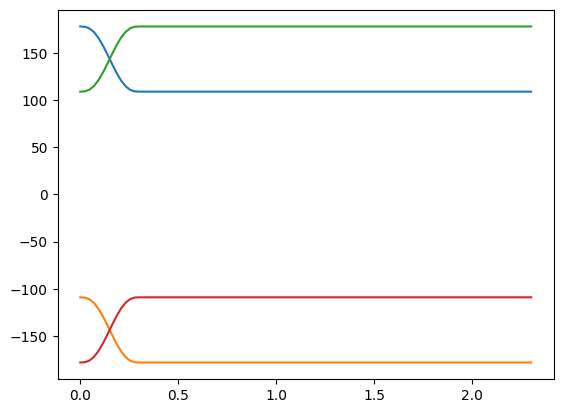

In [6]:
times=np.linspace(0,trajectory_time+2,100)
plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta1_back,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_back,time,trajectory_time)[0] for time in times])

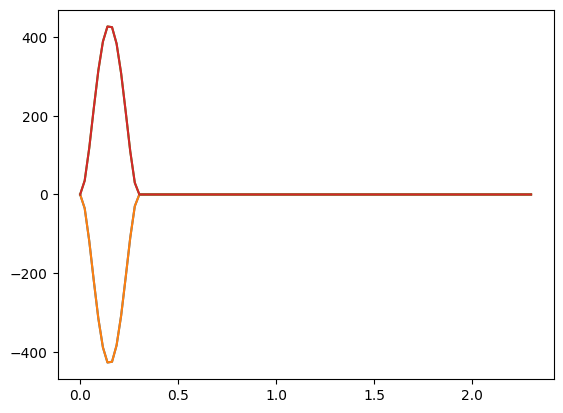

In [7]:
plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta1_back,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_back,time,trajectory_time)[1] for time in times])

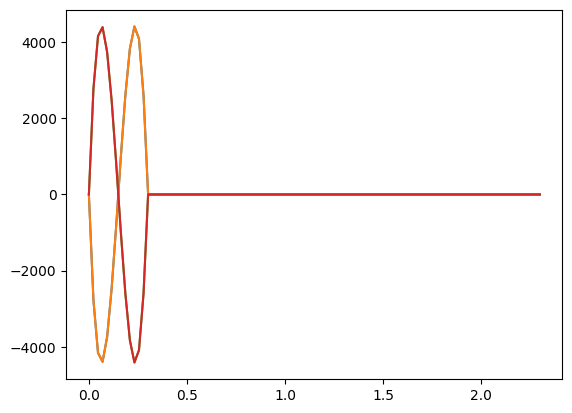

In [8]:
plt.plot(times,[evaluate_quintic(coeffs_theta1_go,time,trajectory_time)[2] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_go,time,trajectory_time)[2] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta1_back,time,trajectory_time)[2] for time in times])
plt.plot(times,[evaluate_quintic(coeffs_theta2_back,time,trajectory_time)[2] for time in times])

In [9]:
robot.set_control_mode("torque")

t_0=time.time()

loops=50

pause_time=0.2
completed=0

data_log = []

current_series_id = 0

end_of_series=False

while completed<loops:
    actual_time=time.time()-t_0
    
    if actual_time<trajectory_time:
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_go,actual_time,trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_go,actual_time,trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_go,actual_time,trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_go,actual_time,trajectory_time)[1]
    elif actual_time<(trajectory_time+pause_time):
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_go,trajectory_time,trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_go,trajectory_time,trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_go,trajectory_time,trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_go,trajectory_time,trajectory_time)[1]
    elif actual_time<(trajectory_time*2+pause_time):
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_back,actual_time-(trajectory_time+pause_time),trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_back,actual_time-(trajectory_time+pause_time),trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_back,actual_time-(trajectory_time+pause_time),trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_back,actual_time-(trajectory_time+pause_time),trajectory_time)[1]
    elif actual_time<(trajectory_time*2+pause_time*2):
        objective_angle_theta1=evaluate_quintic(coeffs_theta1_back,trajectory_time,trajectory_time)[0]
        objective_angle_theta2=evaluate_quintic(coeffs_theta2_back,trajectory_time,trajectory_time)[0]
        
        objective_speed_theta1=evaluate_quintic(coeffs_theta1_back,trajectory_time,trajectory_time)[1]
        objective_speed_theta2=evaluate_quintic(coeffs_theta2_back,trajectory_time,trajectory_time)[1]
    else:
        end_of_series=True
        
    if not end_of_series:
        motor_data = robot.get_motors_data()
        
        data_log.append({
            'time': actual_time,
            'series_id': current_series_id,
            'angle1': motor_data["angle"][0],
            'angle2': motor_data["angle"][1],
            'speed1': motor_data["speed"][0],
            'speed2': motor_data["speed"][1],
            'torque1': motor_data["torque"][0],
            'torque2': motor_data["torque"][1],

        })
        
        actual_theta1=motor_data["angle"][0]
        actual_theta2=motor_data["angle"][1]
        
        actual_speed1=motor_data["speed"][0]
        actual_speed2=motor_data["speed"][1]
        
        
        target1=0.01*(objective_angle_theta1-actual_theta1)+0.005*(objective_speed_theta1-actual_speed1)
        target2=0.01*(objective_angle_theta2-actual_theta2)+0.005*(objective_speed_theta2-actual_speed2)
        
        robot.set_target(target1,target2)
    else:
        t_0=time.time()
        completed+=1
        current_series_id+=1
        end_of_series=False
    time.sleep(0.01)
    
robot.set_target(0,0)

Control Mode set to 'torque'. Setting targets to [0, 0]



In [12]:
trajectory_df=pd.DataFrame(data_log)
trajectory_df.to_csv(os.path.join(os.path.abspath("data"), 'robot_trajectory.csv'), index=False)


In [13]:
unique_series = trajectory_df['series_id'].unique()
print(unique_series)

print(trajectory_df.head())

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
       time  series_id  angle1  angle2  speed1  speed2  torque1  torque2
0  0.000000          0     177    -108       0       0  -0.0540  -0.0765
1  0.011702          0     177    -108       0       0  -0.0540  -0.0630
2  0.022086          0     177    -108       0       0  -0.0000  -0.0225
3  0.032694          0     177    -108       0       0  -0.0225  -0.0405
4  0.043170          0     177    -108       0       0  -0.1620  -0.1800


In [14]:

column_groups = {
    'angle': ('angle1', 'angle2'),
    'speed': ('speed1', 'speed2'),
    'torque': ('torque1', 'torque2')
}

grouped = trajectory_df.groupby('series_id')

# Define widgets
series_idx_slider = widgets.IntSlider(
    value=0, min=0, max=len(unique_series)-1, step=1,
    description='Series Index'
)
variable_group_dropdown = widgets.Dropdown(
    options=['angle', 'speed', 'torque'],
    value='angle',
    description='Variable'
)

# Update the function to accept actual values
def plot_series_optimized(series_idx, variable_group):
    series_id = unique_series[series_idx]
    subset = grouped.get_group(series_id)  # Faster access
    col1, col2 = column_groups[variable_group]

    plt.figure(figsize=(10, 5))
    plt.plot(subset['time'], subset[col1], label=col1, marker='o')
    plt.plot(subset['time'], subset[col2], label=col2, marker='x')
    plt.xlabel('Time')
    plt.ylabel(variable_group.capitalize())
    plt.title(f'{variable_group.capitalize()} for Series ID: {series_id}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Hook widgets to function
out = interactive_output(plot_series_optimized, {
    'series_idx': series_idx_slider,
    'variable_group': variable_group_dropdown
})

# Display
VBox([series_idx_slider, variable_group_dropdown, out])

In [26]:
robot.reactivate()
robot.set_control_mode("position",theta1_pick,theta2_pick)

Control Mode set to 'position'. Setting targets to [177.97408142381062, -108.94326081883368]

